### *Ethics in AI Experiment 4*

github link - https://github.com/PRASHIRAWAL/Ethics-in-AI-Experiments/tree/main/Experiment%204%20-%20NLP%20Sentiment%20Analysis

Implementing a NLP sentiment analysis model


In [ ]:
!pip install datasets nltk

In [ ]:
!pip install vaderSentiment emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 21.2 MB/s eta 0:00:00


## VADER Sentiment Analyzer

VADER (Valence Aware Dictionary and Sentiment Reasoner) is a rule-based sentiment analysis tool designed for analyzing social media text.

It works by assigning sentiment scores to words using a predefined sentiment lexicon and combines them to generate four scores:

• **Positive Score** – Degree of positive sentiment  
• **Negative Score** – Degree of negative sentiment  
• **Neutral Score** – Degree of neutral sentiment  
• **Compound Score** – Overall sentiment score ranging from -1 to +1

The compound score is used to classify the sentiment of the text as positive, negative, or neutral.

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import emoji
import re

In [ ]:
analyzer = SentimentIntensityAnalyzer()

## Emoji Processing

Emojis are widely used in social media communication and often carry strong emotional meaning.

For example:
😊 indicates positive emotion  
😡 indicates anger or negative emotion

Since traditional text processing models cannot directly interpret emojis, they are converted into textual descriptions using the emoji library.

Example:
😊 → smiling_face  
😡 → angry_face

This improves the sentiment analysis accuracy.

In [ ]:
def convert_emojis(text):
    return emoji.demojize(text, delimiters=(" ", " "))

## Sarcasm Detection

Sarcasm is one of the biggest challenges in sentiment analysis because the literal meaning of a sentence may be different from its intended meaning.

Example:

"Great job crashing the server."

Although the sentence contains positive words like "great", the intended sentiment is negative.

To address this issue, sarcasm detection is implemented using:

1. Machine Learning (Logistic Regression)
2. Text vectorization using TF-IDF

The model learns patterns in sarcastic expressions and helps improve sentiment classification accuracy.

In [ ]:
def detect_sarcasm(text):

    sarcasm_patterns = [
        r"yeah right",
        r"as if",
        r"great job",
        r"wow amazing",
        r"just what i needed",
        r"perfect",
        r"love that for me"
    ]

    text_lower = text.lower()

    for pattern in sarcasm_patterns:
        if re.search(pattern, text_lower):
            return True

    if "🙄" in text or "😒" in text:
        return True

    return False

In [ ]:
def analyze_sentiment(text):

    original_text = text

    # Convert emojis
    text = convert_emojis(text)

    # Detect sarcasm
    sarcasm = detect_sarcasm(original_text)

    scores = analyzer.polarity_scores(text)

    compound = scores['compound']

    if compound >= 0.05:
        sentiment = "Positive"
    elif compound <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    if sarcasm:
        sentiment = "Possible Sarcasm Detected"

    return {
        "text": original_text,
        "sentiment": sentiment,
        "scores": scores,
        "sarcasm": sarcasm
    }

## Sentiment Prediction

The sentiment prediction process combines:

1. Emoji processing
2. Sarcasm detection
3. VADER sentiment analysis

First, emojis are converted to text form.  
Then sarcasm is detected using the trained machine learning model.  
Finally, the VADER sentiment analyzer calculates the compound sentiment score.

If sarcasm is detected, the sentiment is adjusted accordingly to better reflect the intended meaning.

In [ ]:
samples = [
    "I love this phone 😍",
    "This is the worst service ever 😡",
    "Yeah right, great job ruining everything 🙄",
    "The movie was okay 🙂",
    "Perfect! Another assignment due tomorrow 😒"
]

for s in samples:
    result = analyze_sentiment(s)

    print("\nText:", result["text"])
    print("Sentiment:", result["sentiment"])
    print("Scores:", result["scores"])
    print("Sarcasm:", result["sarcasm"])


Text: I love this phone 😍
Sentiment: Positive
Scores: {'neg': 0.0, 'neu': 0.488, 'pos': 0.512, 'compound': 0.6369}
Sarcasm: False

Text: This is the worst service ever 😡
Sentiment: Negative
Scores: {'neg': 0.406, 'neu': 0.594, 'pos': 0.0, 'compound': -0.6249}
Sarcasm: False

Text: Yeah right, great job ruining everything 🙄
Sentiment: Possible Sarcasm Detected
Scores: {'neg': 0.163, 'neu': 0.325, 'pos': 0.512, 'compound': 0.6486}
Sarcasm: True

Text: The movie was okay 🙂
Sentiment: Positive
Scores: {'neg': 0.0, 'neu': 0.678, 'pos': 0.322, 'compound': 0.2263}
Sarcasm: False

Text: Perfect! Another assignment due tomorrow 😒
Sentiment: Possible Sarcasm Detected
Scores: {'neg': 0.0, 'neu': 0.556, 'pos': 0.444, 'compound': 0.6114}
Sarcasm: True


The above is a very basic Sentiment Analysis model that does emoji handling and basic sarcasm detection

### **The below one is a Sentiment Analysis Model with improved implementation uses Vader, with twitter dataset, emoji handling and advanced sarcasm detection**

Installing the required libraries

In [ ]:
!pip install vaderSentiment emoji scikit-learn pandas matplotlib seaborn

Importing the libraries

In [ ]:
import pandas as pd
import re
import emoji
import seaborn as sns
import matplotlib.pyplot as plt

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("twitter_training.csv", engine='python', on_bad_lines='warn')

df.head(100)

/tmp/ipykernel_151/1427597066.py:1: ParserWarning: Skipping line 7334: ',' expected after '"'

  df = pd.read_csv("twitter_training.csv", engine='python', on_bad_lines='warn')
/tmp/ipykernel_151/1427597066.py:1: ParserWarning: Skipping line 53997: ',' expected after '"'

  df = pd.read_csv("twitter_training.csv", engine='python', on_bad_lines='warn')
/tmp/ipykernel_151/1427597066.py:1: ParserWarning: Skipping line 14855: Expected 4 fields in line 14855, saw 6

  df = pd.read_csv("twitter_training.csv", engine='python', on_bad_lines='warn')


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
95,2417,Borderlands,Negative,Grounded almost looked pretty cool even despit...
96,2417,Borderlands,Negative,Grounded looked cool despite the borderline un...
97,2417,Borderlands,Negative,"Grosskreutz looked pretty cool, even despite t..."
98,2417,Borderlands,Negative,Grounded almost looked pretty cool here despit...


In [ ]:
df.columns = ["id", "game", "sentiment", "tweet"]

df.head()

,id,game,sentiment,tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [ ]:
print(df.shape)
df["sentiment"].value_counts()

(103044, 4)


,count
sentiment,
Negative,32783
Positive,27943
Neutral,25142
Irrelevant,17174


In [ ]:
df = df[df["sentiment"] != "Irrelevant"]
df = df.dropna(subset=['sentiment'])

In [ ]:
df["sentiment"] = df["sentiment"].str.lower()

In [ ]:
!pip install vaderSentiment emoji seaborn scikit-learn

In [ ]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
def convert_emojis(text):
    return emoji.demojize(str(text))

In [ ]:
def detect_sarcasm(text):

    text = str(text).lower()

    sarcasm_words = [
        "yeah right",
        "as if",
        "great job",
        "perfect",
        "just what i needed",
        "wow amazing",
        "nice work"
    ]

    sarcastic_emojis = ["🙄","😒","😑"]

    for word in sarcasm_words:
        if word in text:
            return True

    for e in sarcastic_emojis:
        if e in text:
            return True

    return False

In [ ]:
def predict_sentiment(text):

    text = convert_emojis(text)

    sarcasm = detect_sarcasm(text)

    score = analyzer.polarity_scores(text)

    compound = score["compound"]

    if compound >= 0.05:
        sentiment = "positive"

    elif compound <= -0.05:
        sentiment = "negative"

    else:
        sentiment = "neutral"

    if sarcasm:
        sentiment = "negative"

    return sentiment

In [ ]:
df["predicted_sentiment"] = df["tweet"].apply(predict_sentiment)

df.head()

,id,game,sentiment,tweet,predicted_sentiment
0,2401,Borderlands,positive,I am coming to the borders and I will kill you...,negative
1,2401,Borderlands,positive,im getting on borderlands and i will kill you ...,negative
2,2401,Borderlands,positive,im coming on borderlands and i will murder you...,negative
3,2401,Borderlands,positive,im getting on borderlands 2 and i will murder ...,negative
4,2401,Borderlands,positive,im getting into borderlands and i can murder y...,negative


In [ ]:
accuracy = accuracy_score(df["sentiment"], df["predicted_sentiment"])

print("Model Accuracy:", accuracy)

Model Accuracy: 0.49092793590161643


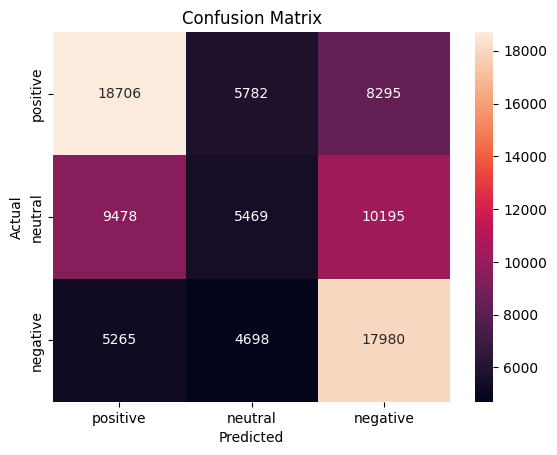

In [ ]:
cm = confusion_matrix(df["sentiment"], df["predicted_sentiment"])

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=["positive","neutral","negative"],
            yticklabels=["positive","neutral","negative"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
samples = [
    "I love this game 😍",
    "Worst update ever",
    "Yeah right great job 🙄",
    "The gameplay is okay"
]

for s in samples:
    print(s, "->", predict_sentiment(s))

I love this game 😍 -> positive
Worst update ever -> negative
Yeah right great job 🙄 -> negative
The gameplay is okay -> positive


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [ ]:
def sarcasm_label(text):

    text = str(text).lower()

    sarcasm_patterns = [
        "yeah right",
        "as if",
        "great job",
        "perfect",
        "just what i needed",
        "wow amazing",
        "love that for me"
    ]

    for pattern in sarcasm_patterns:
        if pattern in text:
            return 1

    return 0


df["sarcasm"] = df["tweet"].apply(sarcasm_label)

df.head()

,id,game,sentiment,tweet,predicted_sentiment,sarcasm
0,2401,Borderlands,positive,I am coming to the borders and I will kill you...,negative,0
1,2401,Borderlands,positive,im getting on borderlands and i will kill you ...,negative,0
2,2401,Borderlands,positive,im coming on borderlands and i will murder you...,negative,0
3,2401,Borderlands,positive,im getting on borderlands 2 and i will murder ...,negative,0
4,2401,Borderlands,positive,im getting into borderlands and i can murder y...,negative,0


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

# Fill NaN values in 'tweet' column with an empty string
df['tweet'] = df['tweet'].fillna('')

X = vectorizer.fit_transform(df["tweet"])

y = df["sarcasm"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
sarcasm_model = LogisticRegression()

sarcasm_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
sarcasm_predictions = sarcasm_model.predict(X_test)

In [ ]:
print("Sarcasm Detection Report\n")

print(classification_report(y_test, sarcasm_predictions))

Sarcasm Detection Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17000
           1       1.00      0.55      0.71       174

    accuracy                           1.00     17174
   macro avg       1.00      0.78      0.85     17174
weighted avg       1.00      1.00      0.99     17174



In [ ]:
def detect_sarcasm_ml(text):

    sarcastic_emojis = ["🙄","😒","😑"]

    for e in sarcastic_emojis:
        if e in text:
            return True

    text_vec = vectorizer.transform([text])

    pred = sarcasm_model.predict(text_vec)

    return bool(pred[0])

In [ ]:
def predict_sentiment(text):

    text_processed = convert_emojis(text)

    sarcasm = detect_sarcasm_ml(text)

    scores = analyzer.polarity_scores(text_processed)

    compound = scores["compound"]

    if compound >= 0.05:
        sentiment = "positive"

    elif compound <= -0.05:
        sentiment = "negative"

    else:
        sentiment = "neutral"

    # Sarcasm override
    if sarcasm:
        sentiment = "negative"

    return sentiment

In [ ]:
df["predicted_sentiment"] = df["tweet"].apply(predict_sentiment)

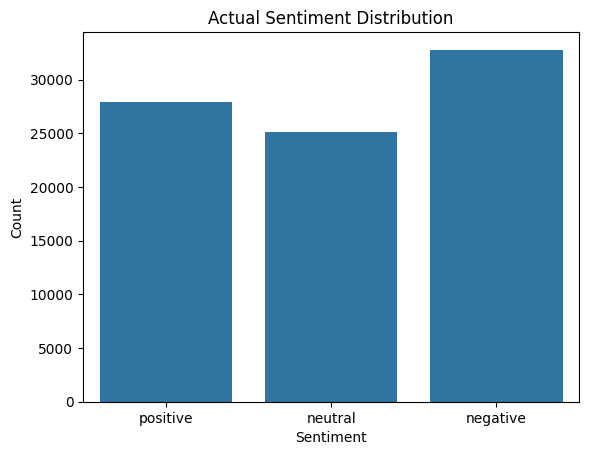

In [ ]:
sns.countplot(x=df["sentiment"])

plt.title("Actual Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

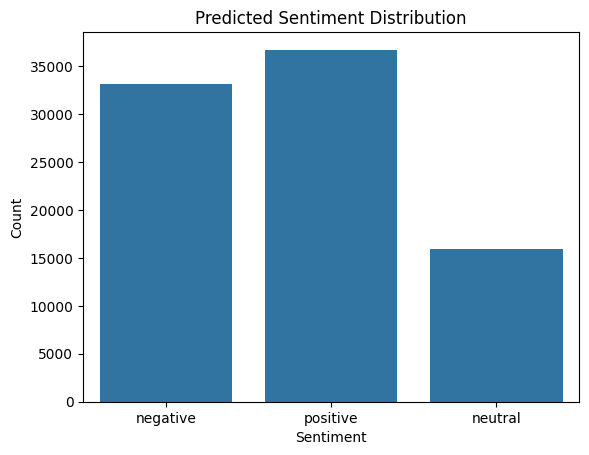

In [ ]:
sns.countplot(x=df["predicted_sentiment"])

plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [ ]:
df_compare = pd.DataFrame({
    "Actual": df["sentiment"],
    "Predicted": df["predicted_sentiment"]
})

df_compare.head()

,Actual,Predicted
0,positive,negative
1,positive,negative
2,positive,negative
3,positive,negative
4,positive,negative


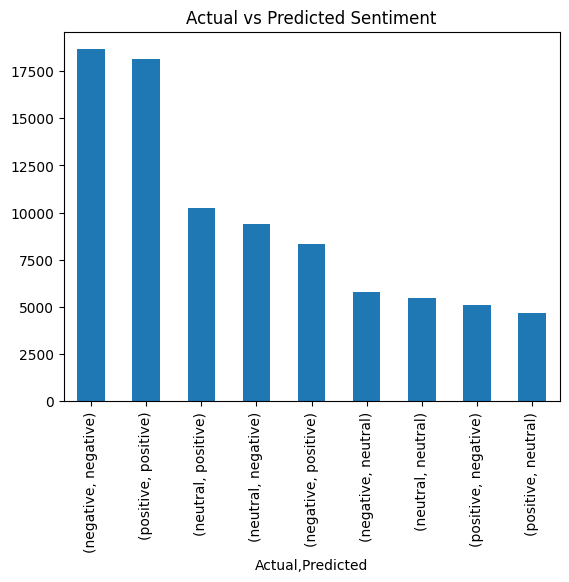

In [ ]:
df_compare.value_counts().plot(kind="bar")

plt.title("Actual vs Predicted Sentiment")

plt.show()

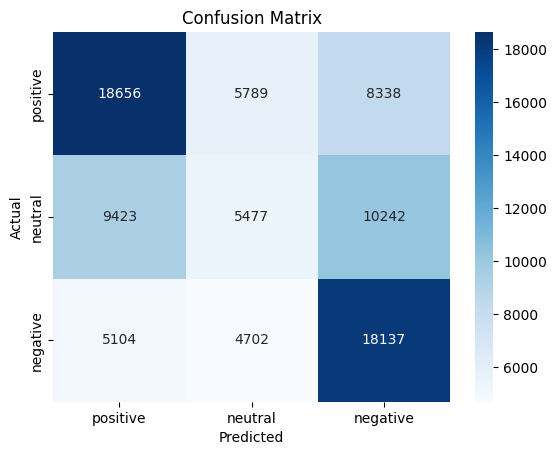

In [ ]:
cm = confusion_matrix(df["sentiment"], df["predicted_sentiment"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["positive","neutral","negative"],
    yticklabels=["positive","neutral","negative"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
examples = [
    "I love this game 😍",
    "Worst update ever",
    "Yeah right great job 🙄",
    "Perfect! another bug in the system"
]

for e in examples:
    print(e, "->", predict_sentiment(e))

I love this game 😍 -> positive
Worst update ever -> negative
Yeah right great job 🙄 -> negative
Perfect! another bug in the system -> negative


## Ethical Considerations in Sentiment Analysis

Although sentiment analysis is useful for understanding opinions on social media, it raises several ethical concerns:

1. **Bias in Language Interpretation**
   Sentiment models may misinterpret slang, sarcasm, or cultural expressions.

2. **Context Misinterpretation**
   Words like "kill" or "destroy" may appear negative but can be used in gaming contexts.

3. **Privacy Concerns**
   Analyzing social media data may raise privacy issues if user data is collected without consent.

4. **Algorithmic Misclassification**
   Automated systems may incorrectly interpret emotions, which could lead to incorrect conclusions.

Therefore, sentiment analysis systems should be used responsibly with human oversight.